# Exploratory Data Analysis (EDA)

Loads all CSV files from a user-defined folder and performs a structured EDA.

| Section | Content |
|---|---|
| **1. Per-File** | Descriptive stats · Kurtosis & Skewness · Histograms · Correlation matrix |
| **2. Aggregate** | Global stats on concatenated data · Cross-file summary · Aggregate histograms · Correlation matrices |

> Per-file **plots** are capped at `MAX_FILES_DISPLAY` to keep the output manageable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
load_from_dir = "../data/replication_returns_other_post2001"  # <-- set your folder here

# Max files for which per-file PLOTS are rendered (set None to plot all files)
MAX_FILES_DISPLAY = 5
# ─────────────────────────────────────────────────────────────────────────────

---
## 0. Data Loading

In [3]:
csv_paths = sorted(Path(load_from_dir).glob("*.csv"))
assert len(csv_paths) > 0, f"No CSV files found in '{load_from_dir}'"

dataframes = {p.stem: pd.read_csv(p) for p in csv_paths}
print(f"Loaded {len(dataframes)} file(s) from '{load_from_dir}'")

# Schema check
schemas = {name: tuple(df.columns.tolist()) for name, df in dataframes.items()}
unique_schemas = set(schemas.values())
if len(unique_schemas) == 1:
    cols = list(unique_schemas)[0]
    print(f"Shared schema ({len(cols)} columns): {cols}")
else:
    print(f"WARNING: {len(unique_schemas)} different schemas detected.")
    for schema in unique_schemas:
        count = sum(1 for v in schemas.values() if v == schema)
        print(f"  {schema}  →  {count} file(s)")

Loaded 210 file(s) from '../data/replication_returns_other_post2001'
Shared schema (2 columns): ('date', 'log_adj_close')


---
## 1. Per-File Statistics

For each CSV: descriptive statistics (mean, median, std, min, max), kurtosis, skewness, histograms, and correlation matrix.

### 1.1 Descriptive Statistics per File

In [4]:
summary_rows = []

for name, df in dataframes.items():
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    desc   = num_df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    median = num_df.median().rename('median')
    kurt   = num_df.kurtosis().rename('kurtosis')
    skew   = num_df.skew().rename('skewness')

    extended = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
    row_order = ['count', 'mean', 'median', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'kurtosis', 'skewness']
    extended  = extended.reindex([r for r in row_order if r in extended.index])

    print(f"\n{'─'*60}\n  {name}\n{'─'*60}")
    display(extended)

    # Collect for cross-file summary
    for col in num_df.columns:
        summary_rows.append({
            'file':     name,
            'column':   col,
            'mean':     num_df[col].mean(),
            'median':   num_df[col].median(),
            'std':      num_df[col].std(),
            'min':      num_df[col].min(),
            'max':      num_df[col].max(),
            'kurtosis': num_df[col].kurtosis(),
            'skewness': num_df[col].skew(),
        })

per_file_summary = pd.DataFrame(summary_rows)


────────────────────────────────────────────────────────────
  AAPL_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


,log_adj_close
count,6107.0000
mean,0.0011
median,0.0010
std,0.0211
min,-0.1975
5%,-0.0320
25%,-0.0089
50%,0.0010
75%,0.0119
95%,0.0339



────────────────────────────────────────────────────────────
  ABT_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


,log_adj_close
count,6107.0000
mean,0.0003
median,0.0004
std,0.0145
min,-0.1760
5%,-0.0212
25%,-0.0066
50%,0.0004
75%,0.0078
95%,0.0215



────────────────────────────────────────────────────────────
  ADI_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


...

,log_adj_close
count,6107.0000
mean,0.0002
median,0.0005
std,0.0205
min,-0.2571
5%,-0.0302
25%,-0.0096
50%,0.0005
75%,0.0101
95%,0.0300



────────────────────────────────────────────────────────────
  XEL_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


,log_adj_close
count,6107.0000
mean,0.0003
median,0.0006
std,0.0167
min,-0.4583
5%,-0.0203
25%,-0.0059
50%,0.0006
75%,0.0074
95%,0.0192



────────────────────────────────────────────────────────────
  XOM_2002-01-02_2026-04-10
────────────────────────────────────────────────────────────


,log_adj_close
count,6107.0000
mean,0.0004
median,0.0005
std,0.0164
min,-0.1503
5%,-0.0243
25%,-0.0076
50%,0.0005
75%,0.0087
95%,0.0242


### 1.2 Per-File Histograms
> Limited to the first `MAX_FILES_DISPLAY` files.

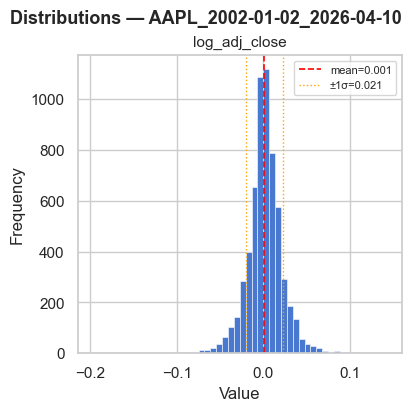

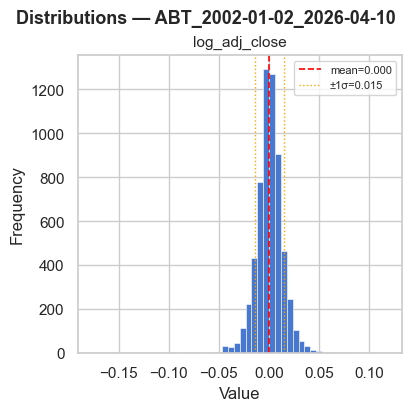

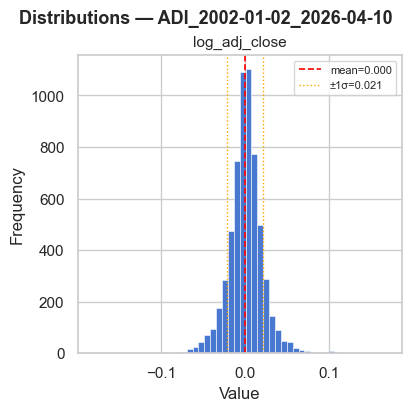

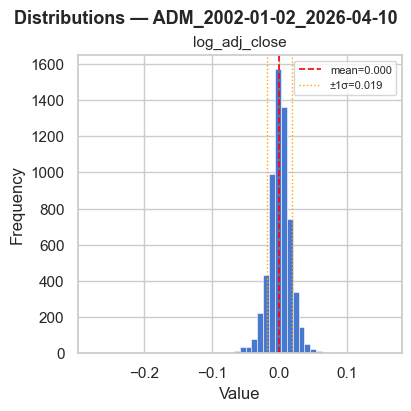

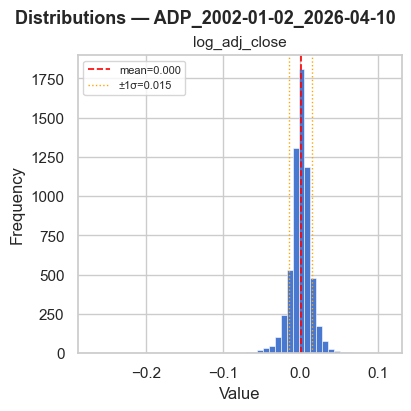

In [5]:
plot_items = list(dataframes.items())
if MAX_FILES_DISPLAY is not None:
    plot_items = plot_items[:MAX_FILES_DISPLAY]

for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    n_cols = len(num_df.columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, num_df.columns):
        data = num_df[col].dropna()
        ax.hist(data, bins=50, edgecolor='white', linewidth=0.4)
        mu, sigma = data.mean(), data.std()
        ax.axvline(mu, color='red',    linestyle='--', linewidth=1.2, label=f'mean={mu:.3f}')
        ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.0)
        ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.0, label=f'\u00b11\u03c3={sigma:.3f}')
        ax.set_title(col, fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    fig.suptitle(f"Distributions \u2014 {name}", fontsize=13, fontweight='bold')
    plt.show()

### 1.3 Per-File Correlation Matrix
> Limited to the first `MAX_FILES_DISPLAY` files.

In [6]:
for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.shape[1] < 2:
        print(f"{name}: only one numeric column, correlation skipped.")
        continue

    corr = num_df.corr()
    size = max(4, len(corr) * 0.9 + 1)
    fig, ax = plt.subplots(figsize=(size, size * 0.8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f"Correlation Matrix \u2014 {name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

AAPL_2002-01-02_2026-04-10: only one numeric column, correlation skipped.
ABT_2002-01-02_2026-04-10: only one numeric column, correlation skipped.
ADI_2002-01-02_2026-04-10: only one numeric column, correlation skipped.
ADM_2002-01-02_2026-04-10: only one numeric column, correlation skipped.
ADP_2002-01-02_2026-04-10: only one numeric column, correlation skipped.


In [7]:
# ── Increments: x_t − x_{t-1} ──────────────────────────────────────────────
inc_summary_rows = []
inc_dataframes   = {}   # {name: diff_df}  reused in the aggregate cells below

for name, df in dataframes.items():
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    diff_df = num_df.diff().dropna()          # shape (T-1, K)
    inc_dataframes[name] = diff_df

    desc   = diff_df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    median = diff_df.median().rename('median')
    kurt   = diff_df.kurtosis().rename('kurtosis')
    skew   = diff_df.skew().rename('skewness')

    extended  = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
    row_order = ['count', 'mean', 'median', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'kurtosis', 'skewness']
    extended  = extended.reindex([r for r in row_order if r in extended.index])

    print(f"\n{'─'*60}\n  {name}  [increments]\n{'─'*60}")
    display(extended)

    for col in diff_df.columns:
        inc_summary_rows.append({
            'file':     name,
            'column':   col,
            'mean':     diff_df[col].mean(),
            'median':   diff_df[col].median(),
            'std':      diff_df[col].std(),
            'min':      diff_df[col].min(),
            'max':      diff_df[col].max(),
            'kurtosis': diff_df[col].kurtosis(),
            'skewness': diff_df[col].skew(),
        })

inc_per_file_summary = pd.DataFrame(inc_summary_rows)


────────────────────────────────────────────────────────────
  AAPL_2002-01-02_2026-04-10  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,6106.0000
mean,-0.0000
median,-0.0007
std,0.0301
min,-0.2509
5%,-0.0459
25%,-0.0151
50%,-0.0007
75%,0.0151
95%,0.0469



────────────────────────────────────────────────────────────
  ABT_2002-01-02_2026-04-10  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,6106.0000
mean,-0.0000
median,-0.0002
std,0.0209
min,-0.1914
5%,-0.0306
25%,-0.0105
50%,-0.0002
75%,0.0107
95%,0.0317



────────────────────────────────────────────────────────────
  ADI_2002-01-02_2026-04-10  [increments]
────────────────────────────────────────────────────────────


...

,log_adj_close
count,6106.0000
mean,0.0000
median,-0.0001
std,0.0295
min,-0.4181
5%,-0.0426
25%,-0.0144
50%,-0.0001
75%,0.0146
95%,0.0427



────────────────────────────────────────────────────────────
  XEL_2002-01-02_2026-04-10  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,6106.0000
mean,-0.0000
median,-0.0000
std,0.0239
min,-0.4693
5%,-0.0287
25%,-0.0101
50%,-0.0000
75%,0.0100
95%,0.0280



────────────────────────────────────────────────────────────
  XOM_2002-01-02_2026-04-10  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,6106.0000
mean,-0.0000
median,-0.0004
std,0.0241
min,-0.1707
5%,-0.0348
25%,-0.0120
50%,-0.0004
75%,0.0117
95%,0.0351


In [8]:
# ── Aggregate increments statistics (all files combined) ────────────────────
inc_common_cols = sorted(
    set.intersection(*[set(d.columns) for d in inc_dataframes.values()])
)
inc_combined = pd.concat(
    [d[inc_common_cols] for d in inc_dataframes.values()],
    ignore_index=True
)
print(f"Increments combined: {len(inc_combined):,} rows x {len(inc_common_cols)} columns")
print(f"Columns: {inc_common_cols}\n")

desc   = inc_combined.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
median = inc_combined.median().rename('median')
kurt   = inc_combined.kurtosis().rename('kurtosis')
skew   = inc_combined.skew().rename('skewness')

inc_agg_stats = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
row_order     = ['count', 'mean', 'median', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'kurtosis', 'skewness']
inc_agg_stats = inc_agg_stats.reindex([r for r in row_order if r in inc_agg_stats.index])

print("Aggregate Descriptive Statistics — increments (all files combined):")
display(inc_agg_stats)

# ── Cross-file summary ───────────────────────────────────────────────────────
inc_cross_file = (
    inc_per_file_summary
    .groupby('column')[['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skewness']]
    .agg(['mean', 'std'])
)
inc_cross_file.columns = [f"{stat}_{agg}" for stat, agg in inc_cross_file.columns]
print("\nCross-file summary — increments:")
display(inc_cross_file)

Increments combined: 1,282,260 rows x 1 columns
Columns: ['log_adj_close']

Aggregate Descriptive Statistics — increments (all files combined):


,log_adj_close
count,1282260.0000
mean,-0.0000
median,-0.0002
std,0.0289
min,-0.8481
5%,-0.0404
25%,-0.0129
50%,-0.0002
75%,0.0127
95%,0.0408



Cross-file summary — increments:


,mean_mean,mean_std,median_mean,median_std,std_mean,std_std,min_mean,min_std,max_mean,max_std,kurtosis_mean,kurtosis_std,skewness_mean,skewness_std
column,,,,,,,,,,,,,,
log_adj_close,-0.0000,0.0000,-0.0002,0.0002,0.0281,0.0069,-0.2830,0.1152,0.3174,0.1548,16.7340,21.1068,0.3181,0.4006


In [9]:
# Define your condition — edit this
def condition(col: pd.Series) -> pd.Series:
    return (col > 1) & (col.abs() == col.abs().max())   # example: largest positive spike

# ── Search across all files ──────────────────────────────────────────────────
hits = []
for name, diff_df in inc_dataframes.items():
    for col in inc_common_cols:
        mask = condition(diff_df[col])
        matched = diff_df[col][mask]
        if matched.empty:
            continue
        # diff_df index = original df index - 1 (due to .diff().dropna())
        for idx, val in matched.items():
            hits.append({
                'file':        name,
                'column':      col,
                'diff_index':  idx,               # position in the diff series
                'orig_index':  idx + 1,           # corresponding row in original df
                'value':       val,
            })

hits_df = pd.DataFrame(hits)
display(hits_df)


,file,column,diff_index,orig_index,value
0,STT_2002-01-02_2026-04-10,log_adj_close,1775,1776,1.0291


---
## 2. Aggregate Statistics

Statistics computed over **all files combined** (rows from every CSV concatenated).
The cross-file summary shows per-column statistics averaged across files, giving a
sense of how consistent individual files are relative to the global distribution.

### 2.1 Aggregate Descriptive Statistics

In [10]:
# Build combined dataset on the intersection of numeric columns
common_cols = sorted(
    set.intersection(*[set(df.select_dtypes(include='number').columns)
                       for df in dataframes.values()])
)
combined_df = pd.concat(
    [df[common_cols] for df in dataframes.values()],
    ignore_index=True
)
print(f"Combined dataset: {len(combined_df):,} rows x {len(common_cols)} columns")
print(f"Columns: {common_cols}\n")

# Extended describe
desc   = combined_df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
median = combined_df.median().rename('median')
kurt   = combined_df.kurtosis().rename('kurtosis')
skew   = combined_df.skew().rename('skewness')

agg_stats = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
row_order  = ['count', 'mean', 'median', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'kurtosis', 'skewness']
agg_stats  = agg_stats.reindex([r for r in row_order if r in agg_stats.index])

print("Aggregate Descriptive Statistics (all files combined):")
display(agg_stats)

Combined dataset: 1,282,470 rows x 1 columns
Columns: ['log_adj_close']

Aggregate Descriptive Statistics (all files combined):


,log_adj_close
count,1282470.0000
mean,0.0004
median,0.0006
std,0.0201
min,-0.9363
5%,-0.0281
25%,-0.0081
50%,0.0006
75%,0.0092
95%,0.0280


### 2.2 Cross-File Summary

Mean and standard deviation of each per-file statistic, grouped by column.
High std values indicate heterogeneity across files.

In [11]:
cross_file = (
    per_file_summary
    .groupby('column')[['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skewness']]
    .agg(['mean', 'std'])
)
cross_file.columns = [f"{stat}_{agg}" for stat, agg in cross_file.columns]
display(cross_file)

,mean_mean,mean_std,median_mean,median_std,std_mean,std_std,min_mean,min_std,max_mean,max_std,kurtosis_mean,kurtosis_std,skewness_mean,skewness_std
column,,,,,,,,,,,,,,
log_adj_close,0.0004,0.0002,0.0006,0.0002,0.0195,0.0049,-0.2389,0.1365,0.1907,0.0784,20.9160,32.4617,-0.5156,1.0033


### 2.3 Aggregate Histograms

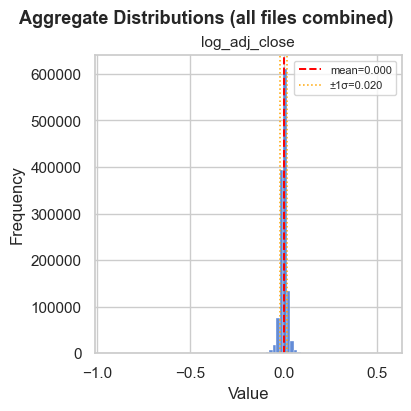

In [12]:
n_cols = len(common_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    data = combined_df[col].dropna()
    ax.hist(data, bins=80, edgecolor='white', linewidth=0.3, alpha=0.85)
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='red',    linestyle='--', linewidth=1.4, label=f'mean={mu:.3f}')
    ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.1)
    ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.1, label=f'\u00b11\u03c3={sigma:.3f}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

fig.suptitle("Aggregate Distributions (all files combined)", fontsize=13, fontweight='bold')
plt.show()

### 2.4 Aggregate Correlation Matrices

Two complementary views:
- **Left** — correlation computed on the full concatenated dataset
- **Right** — element-wise mean of per-file correlation matrices (preserves within-file structure)

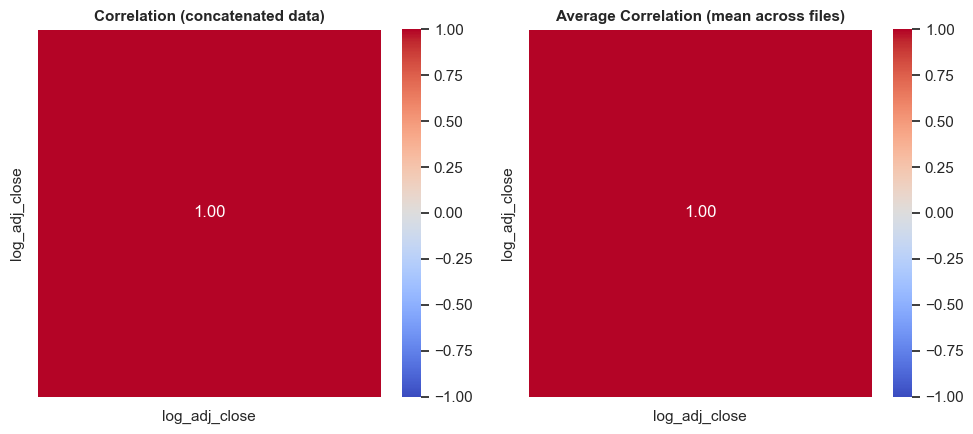

In [13]:
# Per-file correlation matrices stacked
corr_stack = np.array([
    df[common_cols].corr().values
    for df in dataframes.values()
    if df[common_cols].shape[0] > 1
])
avg_corr = pd.DataFrame(corr_stack.mean(axis=0), index=common_cols, columns=common_cols)

size = max(5, len(common_cols) * 1.2 + 1)
fig, axes = plt.subplots(1, 2, figsize=(size * 2, size * 0.9))

# Left: concatenated
corr_combined = combined_df.corr()
sns.heatmap(corr_combined, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Correlation (concatenated data)", fontsize=11, fontweight='bold')

# Right: average across files
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Average Correlation (mean across files)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Per-Window Aggregate Statistics

Sliding windows are built with the **same logic as `SP500WindowDataset`** in `src/utils/dataloader.py`:
- for each file of length *T*, windows start at `s = 0, stride, 2·stride, …` up to `T − seq_len` (inclusive)
- files shorter than `seq_len` are skipped (`drop_incomplete=True`)

Per-window statistics are collected and then aggregated across **all windows**

In [14]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
# Match the values in configs/replication.yaml (train section)
SEQ_LEN = 2048   # seq_len
STRIDE  = 400    # stride
# ─────────────────────────────────────────────────────────────────────────────

In [15]:
# ── Build windows (mirrors SP500WindowDataset logic) ─────────────────────────
value_col = "log_adj_close"   # numeric column to analyse

window_stats = []   # one dict per window

skipped_files = 0
total_windows = 0

for name, df in dataframes.items():
    if value_col not in df.columns:
        continue
    x = df[value_col].to_numpy(dtype=float)
    T = len(x)

    max_start = T - SEQ_LEN
    if max_start < 0:          # drop_incomplete=True: skip short files
        skipped_files += 1
        continue

    for s in range(0, max_start + 1, STRIDE):
        win = x[s : s + SEQ_LEN]        # shape (SEQ_LEN,)
        returns = win          # log-return increments within window

        window_stats.append({
            "file":          name,
            "start":         s,
            # --- level stats ---
            "lev_mean":      win.mean(),
            "lev_std":       win.std(ddof=1),
            "lev_min":       win.min(),
            "lev_max":       win.max(),
            # --- return stats ---
            "ret_mean":      returns.mean(),
            "ret_std":       returns.std(ddof=1),
            "ret_min":       returns.min(),
            "ret_max":       returns.max(),
            "ret_kurtosis":  pd.Series(returns).kurtosis(),
            "ret_skewness":  pd.Series(returns).skew(),
            "ret_abs_mean":  np.abs(returns).mean(),
        })
        total_windows += 1

win_df = pd.DataFrame(window_stats)

print(f"seq_len={SEQ_LEN}  stride={STRIDE}")
print(f"Files processed : {len(dataframes) - skipped_files}  |  skipped (too short): {skipped_files}")
print(f"Total windows   : {total_windows:,}")
display(win_df.head(3))

seq_len=2048  stride=400
Files processed : 210  |  skipped (too short): 0
Total windows   : 2,310


,file,start,lev_mean,lev_std,lev_min,lev_max,ret_mean,ret_std,ret_min,ret_max,ret_kurtosis,ret_skewness,ret_abs_mean
0,AAPL_2002-01-02_2026-04-10,0,0.0014,0.0266,-0.1975,0.1302,0.0014,0.0266,-0.1975,0.1302,3.9555,-0.1611,0.0195
1,AAPL_2002-01-02_2026-04-10,400,0.0018,0.0245,-0.1975,0.1302,0.0018,0.0245,-0.1975,0.1302,4.3309,-0.0711,0.0178
2,AAPL_2002-01-02_2026-04-10,800,0.0011,0.0236,-0.1975,0.1302,0.0011,0.0236,-0.1975,0.1302,5.0078,-0.2823,0.0170


### 3.1 Aggregate Summary across All Windows

In [16]:
stat_cols = [c for c in win_df.columns if c not in ("file", "start")]

agg_win = win_df[stat_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
agg_win = pd.concat([
    agg_win,
    win_df[stat_cols].median().rename('median').to_frame().T,
    win_df[stat_cols].kurtosis().rename('kurtosis').to_frame().T,
    win_df[stat_cols].skew().rename('skewness').to_frame().T,
])
row_order = ['count', 'mean', 'median', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'kurtosis', 'skewness']
agg_win   = agg_win.reindex([r for r in row_order if r in agg_win.index])

print("Aggregate statistics across all windows:")
display(agg_win.T)   # transposed: one row per stat column, one col per statistic

Aggregate statistics across all windows:


,count,mean,median,std,min,5%,25%,50%,75%,95%,max,kurtosis,skewness
lev_mean,2310.0000,0.0004,0.0004,0.0003,-0.0020,-0.0001,0.0002,0.0004,0.0006,0.0009,0.0024,5.1931,-0.5694
lev_std,2310.0000,0.0191,0.0177,0.0064,0.0086,0.0115,0.0148,0.0177,0.0219,0.0309,0.0551,3.7015,1.5562
lev_min,2310.0000,-0.1636,-0.1401,0.1022,-0.9363,-0.2873,-0.1896,-0.1401,-0.1058,-0.0741,-0.0435,19.6221,-3.7015
lev_max,2310.0000,0.1461,0.1328,0.0689,0.0356,0.0667,0.1019,0.1328,0.1679,0.2661,0.5573,7.8613,2.2150
ret_mean,2310.0000,0.0004,0.0004,0.0003,-0.0020,-0.0001,0.0002,0.0004,0.0006,0.0009,0.0024,5.1931,-0.5694
ret_std,2310.0000,0.0191,0.0177,0.0064,0.0086,0.0115,0.0148,0.0177,0.0219,0.0309,0.0551,3.7015,1.5562
ret_min,2310.0000,-0.1636,-0.1401,0.1022,-0.9363,-0.2873,-0.1896,-0.1401,-0.1058,-0.0741,-0.0435,19.6221,-3.7015
ret_max,2310.0000,0.1461,0.1328,0.0689,0.0356,0.0667,0.1019,0.1328,0.1679,0.2661,0.5573,7.8613,2.2150
ret_kurtosis,2310.0000,13.2010,8.7978,23.5615,1.5570,3.2155,5.8288,8.7978,13.8890,29.9074,464.9554,171.0419,11.5338
ret_skewness,2310.0000,-0.3188,-0.2366,0.9509,-14.7055,-1.3569,-0.5265,-0.2366,0.0326,0.4225,12.6860,89.7841,-0.2297


### 3.2 Distribution of Per-Window Return Statistics

In [17]:
ret_plot_cols = ["ret_std", "ret_kurtosis", "ret_skewness", "ret_abs_mean"]
labels        = ["Volatility (ret std)", "Excess Kurtosis", "Skewness", "Mean |return|"]

fig, axes = plt.subplots(1, len(ret_plot_cols), figsize=(5 * len(ret_plot_cols), 4), constrained_layout=True)

for ax, col, label in zip(axes, ret_plot_cols, labels):
    data = win_df[col].dropna()
    ax.hist(data, bins=60, edgecolor='white', linewidth=0.3, alpha=0.85)
    mu = data.mean()
    ax.axvline(mu, color='red', linestyle='--', linewidth=1.3, label=f'mean={mu:.4f}')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('# windows')
    ax.legend(fontsize=8)

fig.suptitle(
    f"Per-Window Return Statistics  (seq_len={SEQ_LEN}, stride={STRIDE}, n={total_windows:,} windows)",
    fontsize=12, fontweight='bold'
)

Text(0.5, 0.98, 'Per-Window Return Statistics  (seq_len=2048, stride=400, n=2,310 windows)')

In [18]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
STD_THRESHOLDS = [1, 2, 3]   # list of X values: count windows with kurtosis > mean + X*std
# ─────────────────────────────────────────────────────────────────────────────

kurt_vals = win_df["ret_kurtosis"].dropna()
kurt_mean = kurt_vals.mean()
kurt_std  = kurt_vals.std(ddof=1)

print(f"Per-window excess kurtosis — mean: {kurt_mean:.3f}  std: {kurt_std:.3f}\n")

rows = []
for x in STD_THRESHOLDS:
    cutoff = kurt_mean + x * kurt_std
    count  = (kurt_vals > cutoff).sum()
    pct    = 100 * count / len(kurt_vals)
    rows.append({
        "threshold": f"mean + {x}σ",
        "cutoff value": round(cutoff, 3),
        "n windows above": int(count),
        "% of all windows": f"{pct:.2f}%",
    })

display(pd.DataFrame(rows).set_index("threshold"))

Per-window excess kurtosis — mean: 13.201  std: 23.562



,cutoff value,n windows above,% of all windows
threshold,,,
mean + 1σ,36.7630,72,3.12%
mean + 2σ,60.3240,36,1.56%
mean + 3σ,83.8860,22,0.95%


### 3.3 Per-File Window Counts

Windows per file — min: 11  median: 11  max: 11


,count,mean,std,min,25%,50%,75%,max
n_windows,210.0000,11.0000,0.0000,11.0000,11.0000,11.0000,11.0000,11.0000


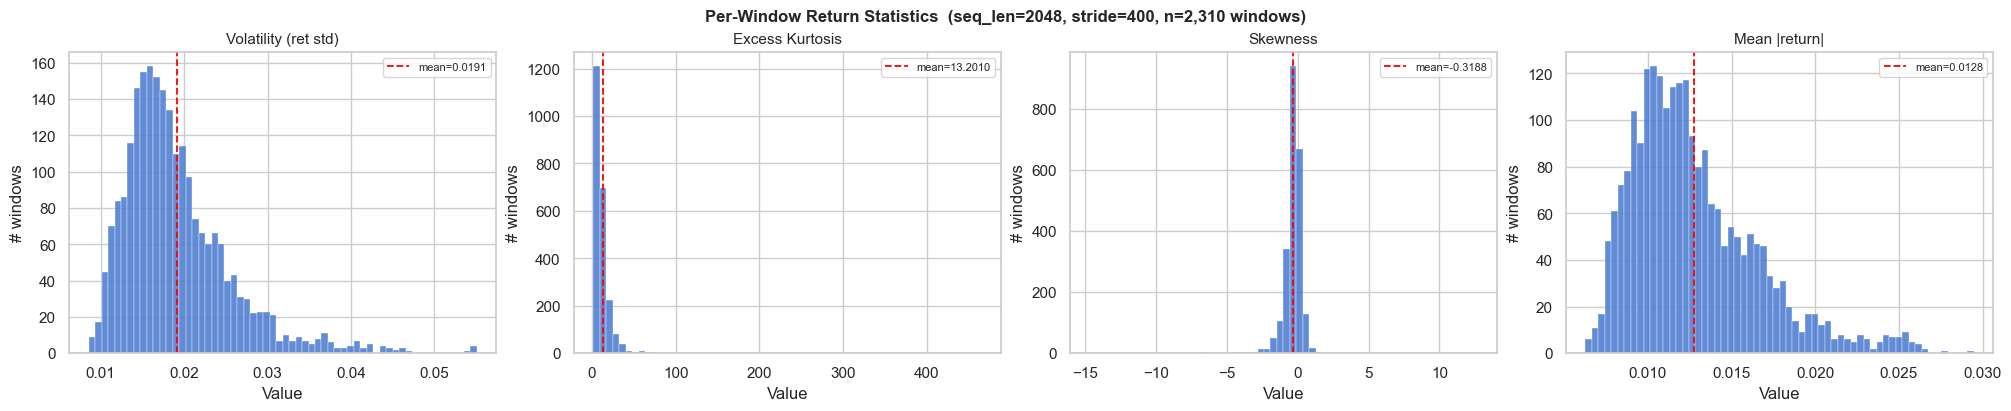

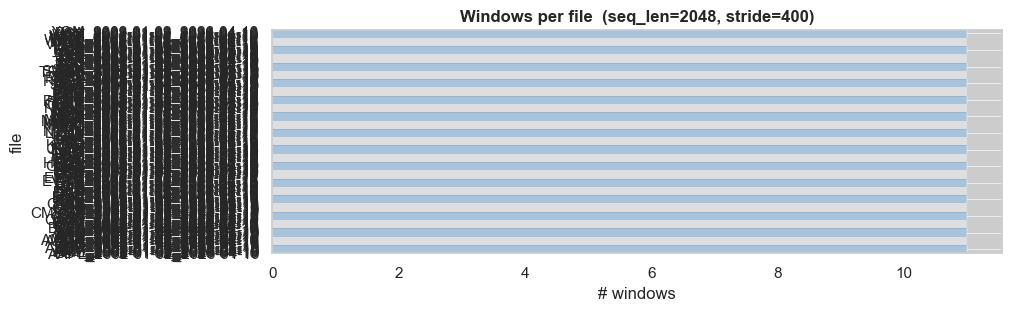

In [19]:
file_counts = win_df.groupby("file").size().rename("n_windows").sort_values(ascending=False)
print(f"Windows per file — min: {file_counts.min()}  median: {file_counts.median():.0f}  max: {file_counts.max()}")
display(file_counts.describe().to_frame().T)

fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
file_counts.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel("# windows")
ax.set_title(f"Windows per file  (seq_len={SEQ_LEN}, stride={STRIDE})", fontweight='bold')
plt.show()